# **Practice Project: Insurance Cost Analysis**

In this project, we have to perform analytics operations on an insurance database that uses the below mentioned parameters.

| Parameter |Description| Content type |
|---|----|---|
|age| Age in years| integer |
|gender| Male or Female|integer (1 or 2)|
| bmi | Body mass index | float |
|no_of_children| Number of children | integer|
|smoker| Whether smoker or not | integer (0 or 1)|
|region| Which US region - NW, NE, SW, SE | integer (1,2,3 or 4 respectively)| 
|charges| Annual Insurance charges in USD | float|

## Objectives 
In this project, we will:
 - Load the data as a `pandas` dataframe
 - Clean the data, taking care of the blank entries
 - Run exploratory data analysis (EDA) and identify the attributes that most affect the `charges`
 - Develop single variable and multi variable Linear Regression models for predicting the `charges`
 - Use Ridge regression to refine the performance of Linear regression models. 
 


# Setup


For this project, we will be using the following libraries:
*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### Importing Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split

### Download the dataset



In [2]:
df = pd.read_csv("1.1_Medical_Insurance_Dataset.csv", header=None)

# Task 1 : Import the dataset

Import the dataset into a `pandas` dataframe. Note that there are currently no headers in the CSV file. 

Print the first 10 rows of the dataframe to confirm successful loading.


In [3]:
print(df.head(10))

    0  1       2  3  4  5            6
0   0  1   2.000  3  4  5      6.00000
1  19  1  27.900  0  1  3  16884.92400
2  18  2  33.770  1  0  4   1725.55230
3  28  2  33.000  3  0  4   4449.46200
4  33  2  22.705  0  0  1  21984.47061
5  32  2  28.880  0  0  1   3866.85520
6  31  1  25.740  0  ?  4   3756.62160
7  46  1  33.440  1  0  4   8240.58960
8  37  1  27.740  3  0  1   7281.50560
9  37  2  29.830  2  0  2   6406.41070


Add the headers to the dataframe, as mentioned in the project scenario. 


In [4]:
headers = ["age", "gender", "bmi", "no_of_children", "smoker", "region", "charges"]
df.columns = headers

In [5]:
df.head()

,age,gender,bmi,no_of_children,smoker,region,charges
0,0,1,2.000,3,4,5,6.00000
1,19,1,27.900,0,1,3,16884.92400
2,18,2,33.770,1,0,4,1725.55230
3,28,2,33.000,3,0,4,4449.46200
4,33,2,22.705,0,0,1,21984.47061


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2773 entries, 0 to 2772
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2773 non-null   str    
 1   gender          2773 non-null   int64  
 2   bmi             2773 non-null   float64
 3   no_of_children  2773 non-null   int64  
 4   smoker          2773 non-null   str    
 5   region          2773 non-null   int64  
 6   charges         2773 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 151.8 KB


Now, replace the '?' entries with 'NaN' values.


In [7]:
df.replace('?', np.nan, inplace = True)

,age,gender,bmi,no_of_children,smoker,region,charges
0,0,1,2.000,3,4,5,6.00000
1,19,1,27.900,0,1,3,16884.92400
2,18,2,33.770,1,0,4,1725.55230
3,28,2,33.000,3,0,4,4449.46200
4,33,2,22.705,0,0,1,21984.47061
...,...,...,...,...,...,...,...
2768,47,1,45.320,1,0,4,8569.86180
2769,21,1,34.600,0,0,3,2020.17700
2770,19,2,26.030,1,1,1,16450.89470
2771,23,2,18.715,0,0,1,21595.38229


# Task 2 : Data Wrangling


Use `dataframe.info()` to identify the columns that have some 'Null' (or NaN) information.


In [8]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2773 entries, 0 to 2772
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2769 non-null   str    
 1   gender          2773 non-null   int64  
 2   bmi             2773 non-null   float64
 3   no_of_children  2773 non-null   int64  
 4   smoker          2766 non-null   str    
 5   region          2773 non-null   int64  
 6   charges         2773 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 151.8 KB
None


Handle missing data:

- For continuous attributes (e.g., age), replace missing values with the mean.
- For categorical attributes (e.g., smoker), replace missing values with the most frequent value.
- Update the data types of the respective columns.
- Verify the update using `df.info()`.


In [9]:
# smoker is a categorical attribute, replace with most frequent entry
is_smoker = df['smoker'].value_counts().idxmax()
df["smoker"] = df["smoker"].fillna(is_smoker)

# age is a continuous variable, replace with mean age
mean_age = df['age'].astype('float').mean(axis=0)
df["age"] = df["age"].fillna(mean_age)

# Update data types
df[["age", "smoker"]] = df[["age", "smoker"]].astype("int")

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2773 entries, 0 to 2772
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2773 non-null   int64  
 1   gender          2773 non-null   int64  
 2   bmi             2773 non-null   float64
 3   no_of_children  2773 non-null   int64  
 4   smoker          2773 non-null   int64  
 5   region          2773 non-null   int64  
 6   charges         2773 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 151.8 KB
None


Also note, that the `charges` column has values which are more than 2 decimal places long. Update the `charges` column such that all values are rounded to nearest 2 decimal places. Verify conversion by printing the first 5 values of the updated dataframe.


In [10]:
df[["charges"]] = np.round(df[["charges"]],2)
print(df.head())

   age  gender     bmi  no_of_children  smoker  region   charges
0    0       1   2.000               3       4       5      6.00
1   19       1  27.900               0       1       3  16884.92
2   18       2  33.770               1       0       4   1725.55
3   28       2  33.000               3       0       4   4449.46
4   33       2  22.705               0       0       1  21984.47


# Task 3 : Exploratory Data Analysis (EDA)

Implement the regression plot for `charges` with respect to `bmi`. 


(0.0, 66974.2099949267)

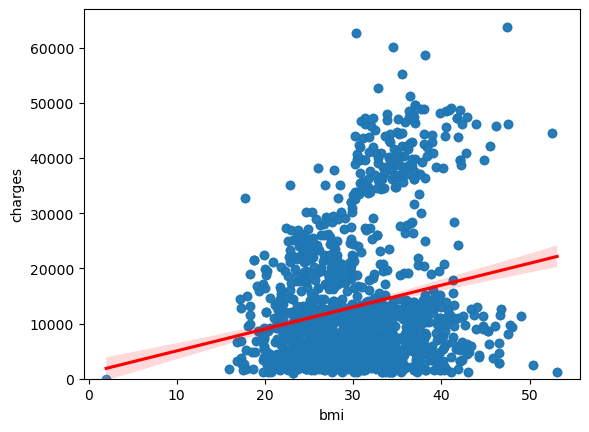

In [11]:
sns.regplot(x="bmi", y="charges", data=df, line_kws={"color": "red"})
plt.ylim(0,)

Implement the box plot for `charges` with respect to `smoker`.


<Axes: xlabel='smoker', ylabel='charges'>

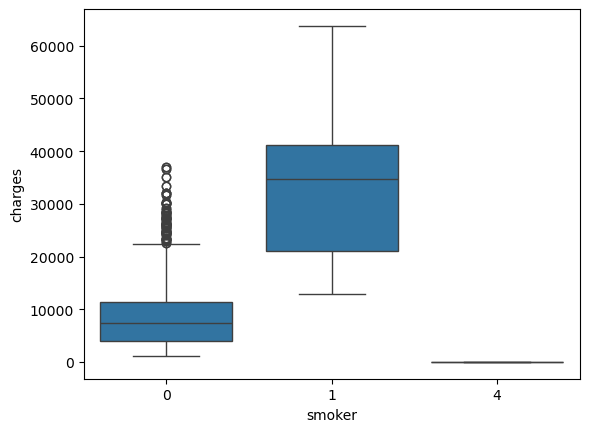

In [12]:
sns.boxplot(x="smoker", y="charges", data=df)

Print the correlation matrix for the dataset.


In [13]:
print(df.corr())

                     age    gender       bmi  no_of_children    smoker  \
age             1.000000 -0.024990  0.117114        0.035943 -0.032176   
gender         -0.024990  1.000000  0.044454        0.015438  0.077627   
bmi             0.117114  0.044454  1.000000       -0.004114 -0.004352   
no_of_children  0.035943  0.015438 -0.004114        1.000000  0.011490   
smoker         -0.032176  0.077627 -0.004352        0.011490  1.000000   
region         -0.009308  0.021401  0.266198       -0.024469  0.060405   
charges         0.299236  0.063211  0.200853        0.065784  0.772612   

                  region   charges  
age            -0.009308  0.299236  
gender          0.021401  0.063211  
bmi             0.266198  0.200853  
no_of_children -0.024469  0.065784  
smoker          0.060405  0.772612  
region          1.000000  0.053152  
charges         0.053152  1.000000  


# Task 4 : Model Development

Fit a linear regression model that may be used to predict the `charges` value, just by using the `smoker` attribute of the dataset. Print the $ R^2 $ score of this model.


In [14]:
X = df[['smoker']]
Y = df['charges']
lm = LinearRegression()
lm.fit(X,Y)
print(lm.score(X, Y))

0.596929987884134


Fit a linear regression model that may be used to predict the `charges` value, just by using all other attributes of the dataset. Print the $ R^2 $ score of this model. You should see an improvement in the performance.


In [15]:
# definition of Y and lm remain same as used in last cell. 
Z = df[["age", "gender", "bmi", "no_of_children", "smoker", "region"]]
lm.fit(Z,Y)
print(lm.score(Z, Y))

0.7336147085213385


Create a training pipeline that uses `StandardScaler()`, `PolynomialFeatures()` and `LinearRegression()` to create a model that can predict the `charges` value using all the other attributes of the dataset. There should be even further improvement in the performance.


In [16]:
# Y and Z use the same values as defined in previous cells 
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model', LinearRegression())]
pipe=Pipeline(Input)
Z = Z.astype(float)
pipe.fit(Z,Y)
ypipe=pipe.predict(Z)
print(r2_score(Y,ypipe))

0.8453240162033773


# Task 5 : Model Refinement

Split the data into training and testing subsets, assuming that 20% of the data will be reserved for testing.


In [17]:
# Z and Y hold same values as in previous cells
x_train, x_test, y_train, y_test = train_test_split(Z, Y, test_size=0.2, random_state=1)

Initialize a Ridge regressor that used hyperparameter $ \alpha = 0.1 $. Fit the model using training data data subset. Print the $ R^2 $ score for the testing data.


In [18]:
RidgeModel=Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train)
yhat = RidgeModel.predict(x_test)
print(r2_score(y_test,yhat))

0.7409290081978699


Apply polynomial transformation to the training parameters with degree=2. Use this transformed feature set to fit the same regression model, as above, using the training subset. Print the $ R^2 $ score for the testing subset.


In [19]:
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.transform(x_test)
RidgeModel.fit(x_train_pr, y_train)
y_hat = RidgeModel.predict(x_test_pr)
print(r2_score(y_test,y_hat))

0.8218412547035207
